In [ ]:
import yfinance as yf
import pandas as pd

# Download 5 years of Apple stock data
df = yf.download("AAPL", start="2019-01-01", end="2024-01-01")
df = df[['Close']]   # we only need the closing price
print(df.head())
print(f"Total rows: {len(df)}")

/tmp/ipykernel_746/1746181222.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", start="2019-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed

Price           Close
Ticker           AAPL
Date                 
2019-01-02  37.469208
2019-01-03  33.736992
2019-01-04  35.177200
2019-01-07  35.098896
2019-01-08  35.767998
Total rows: 1258


In [ ]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import torch
from torch.utils.data import DataLoader, TensorDataset

# --- Scale to [0, 1] ---
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df.values)  # shape: (N, 1)

# --- Create sliding windows ---
def create_sequences(data, seq_len=60):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i : i + seq_len])      # 60 days input
        y.append(data[i + seq_len])           # next day target
    return np.array(X), np.array(y)

SEQ_LEN = 60
X, y = create_sequences(scaled, SEQ_LEN)

# --- Train / Validation / Test split (70/15/15) ---
n = len(X)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

X_train, y_train = X[:train_end], y[:train_end]
X_val,   y_val   = X[train_end:val_end], y[train_end:val_end]
X_test,  y_test  = X[val_end:], y[val_end:]

# --- Convert to PyTorch tensors ---
def to_tensor(arr):
    return torch.tensor(arr, dtype=torch.float32)

X_train_t = to_tensor(X_train)   # shape: (samples, 60, 1)
y_train_t = to_tensor(y_train)
X_val_t   = to_tensor(X_val)
y_val_t   = to_tensor(y_val)
X_test_t  = to_tensor(X_test)
y_test_t  = to_tensor(y_test)

# --- DataLoaders ---
train_ds = TensorDataset(X_train_t, y_train_t)
val_ds   = TensorDataset(X_val_t, y_val_t)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False)

In [ ]:
import torch.nn as nn

class StockLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            dropout     = dropout,
            batch_first = True        # input shape → (batch, seq, features)
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)         # out: (batch, seq_len, hidden)
        return self.fc(out[:, -1, :]) # only last time step

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model  = StockLSTM().to(device)
print(model)

StockLSTM(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [ ]:
import torch.optim as optim

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

EPOCHS = 50
best_val_loss = float('inf')

for epoch in range(1, EPOCHS + 1):
    # --- Training ---
    model.train()
    train_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # prevent exploding gradients
        optimizer.step()
        train_loss += loss.item()

    # --- Validation ---
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            val_loss += criterion(pred, yb).item()

    train_loss /= len(train_loader)
    val_loss   /= len(val_loader)
    scheduler.step(val_loss)

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_model.pth")

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

print("Training complete. Best val loss:", best_val_loss)

Epoch  10 | Train Loss: 0.001199 | Val Loss: 0.001447
Epoch  20 | Train Loss: 0.001018 | Val Loss: 0.001118
Epoch  30 | Train Loss: 0.000918 | Val Loss: 0.000927
Epoch  40 | Train Loss: 0.000881 | Val Loss: 0.000801
Epoch  50 | Train Loss: 0.000645 | Val Loss: 0.002634
Training complete. Best val loss: 0.0007056920876493677


RMSE: $4.71  |  MAE: $4.04


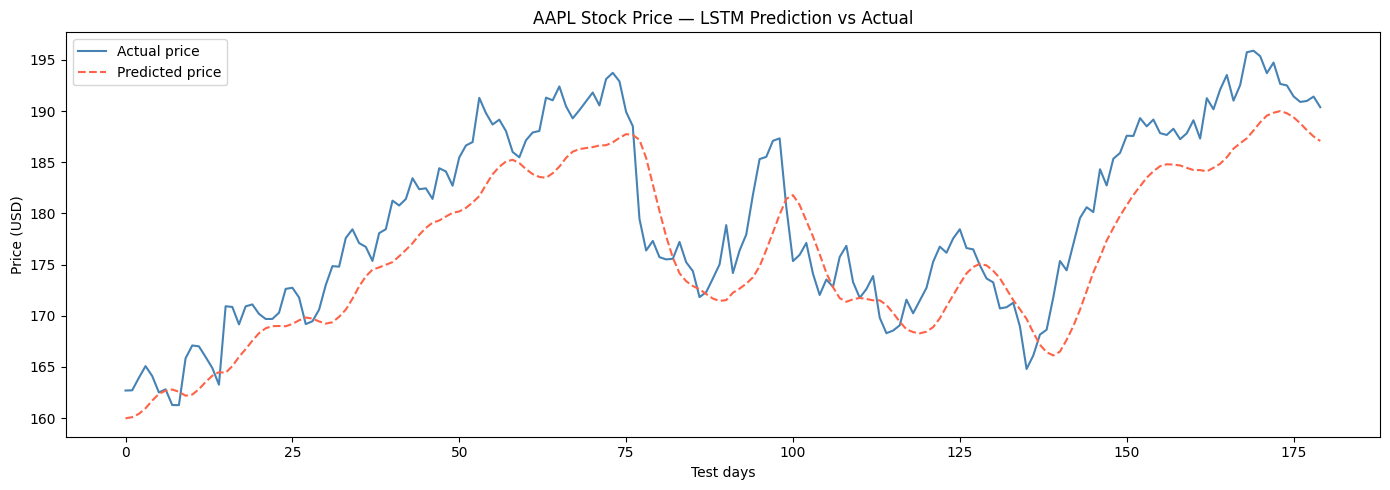

In [ ]:
import matplotlib.pyplot as plt

# Load best weights
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

with torch.no_grad():
    preds_scaled = model(X_test_t.to(device)).cpu().numpy()
    actual_scaled = y_test_t.numpy()

# Inverse-transform back to real prices
preds  = scaler.inverse_transform(preds_scaled)
actual = scaler.inverse_transform(actual_scaled)

# --- Metrics ---
from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse = np.sqrt(mean_squared_error(actual, preds))
mae  = mean_absolute_error(actual, preds)
print(f"RMSE: ${rmse:.2f}  |  MAE: ${mae:.2f}")

# --- Plot ---
plt.figure(figsize=(14, 5))
plt.plot(actual, label="Actual price",    color="steelblue")
plt.plot(preds,  label="Predicted price", color="tomato", linestyle="--")
plt.title("AAPL Stock Price — LSTM Prediction vs Actual")
plt.xlabel("Test days")
plt.ylabel("Price (USD)")
plt.legend()
plt.tight_layout()
plt.savefig("prediction_plot.png", dpi=150)
plt.show()

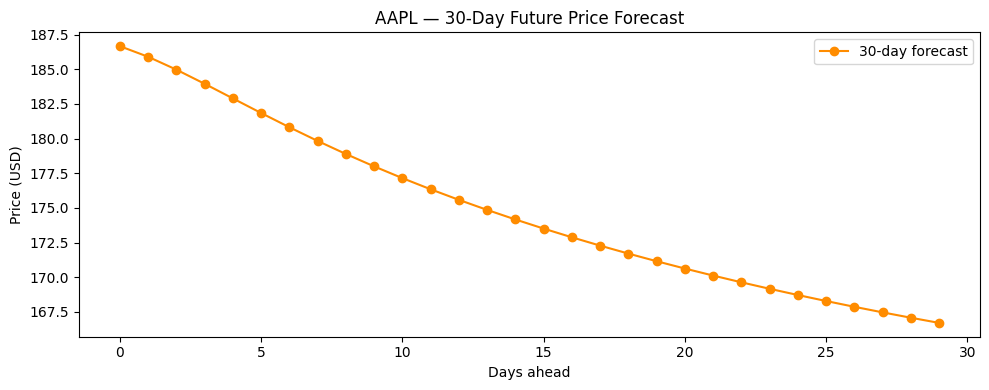

In [ ]:
def predict_future(model, last_sequence, n_days=30, scaler=None):
    """
    last_sequence: numpy array of shape (seq_len, 1), already scaled
    Returns: predicted prices in original scale
    """
    model.eval()
    seq = last_sequence.copy()
    future_preds = []

    with torch.no_grad():
        for _ in range(n_days):
            x = torch.tensor(seq[-SEQ_LEN:], dtype=torch.float32).unsqueeze(0).to(device)
            pred = model(x).cpu().numpy()      # shape (1, 1)
            future_preds.append(pred[0, 0])
            seq = np.append(seq, pred, axis=0) # roll window forward

    future_preds = np.array(future_preds).reshape(-1, 1)
    return scaler.inverse_transform(future_preds)

# Use last SEQ_LEN days as seed
last_seq = scaled[-SEQ_LEN:]
future_prices = predict_future(model, last_seq, n_days=30, scaler=scaler)

plt.figure(figsize=(10, 4))
plt.plot(future_prices, marker="o", color="darkorange", label="30-day forecast")
plt.title("AAPL — 30-Day Future Price Forecast")
plt.xlabel("Days ahead")
plt.ylabel("Price (USD)")
plt.legend()
plt.tight_layout()
plt.show()